In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Load data
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_val = pd.read_csv('y_val.csv')
y_test = pd.read_csv('y_test.csv')


In [9]:
# Convert all text entries to string and fill missing values
X_train['clean_tweet'] = X_train['clean_tweet'].fillna('').astype(str)
X_val['clean_tweet'] = X_val['clean_tweet'].fillna('').astype(str)
X_test['clean_tweet'] = X_test['clean_tweet'].fillna('').astype(str)

# Tokenize and pad
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train['clean_tweet'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train['clean_tweet']), maxlen=100)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val['clean_tweet']), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test['clean_tweet']), maxlen=100)


In [7]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train.values.ravel())
y_val_enc = le.transform(y_val.values.ravel())
y_test_enc = le.transform(y_test.values.ravel())

# Print class mapping (important to know which is 'positive' or 'negative')
print(dict(zip(le.classes_, le.transform(le.classes_))))


{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [21]:

# Define sequence length and vocabulary size
max_len = 100  # should match your padding length
vocab_size = 5000  # should match tokenizer num_words
embedding_dim = 128
num_classes = len(np.unique(y_train_enc))  # inferred from encoded labels

# Build model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Manually build the model to avoid unbuilt summary
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,517 (2.99 MB)

 Trainable params: 784,517 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=3,
    batch_size=128
)


Epoch 1/3
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 627s 292ms/step - accuracy: 0.6442 - loss: 0.9837 - val_accuracy: 0.7247 - val_loss: 0.7855
Epoch 2/3
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 614s 290ms/step - accuracy: 0.7392 - loss: 0.7532 - val_accuracy: 0.7417 - val_loss: 0.7478
Epoch 3/3
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 668s 315ms/step - accuracy: 0.7584 - loss: 0.7040 - val_accuracy: 0.7495 - val_loss: 0.7229


In [16]:
y_pred_proba = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_proba, axis=1)

conf_matrix = confusion_matrix(y_test_enc, y_pred)
accuracy = accuracy_score(y_test_enc, y_pred)
f1_scores = f1_score(y_test_enc, y_pred, average=None)
auc_score = roc_auc_score(y_test_enc, y_pred_proba, multi_class='ovr')

print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Scores (per class): {f1_scores}")
print(f"AUC Score: {auc_score:.4f}")


2821/2821 ━━━━━━━━━━━━━━━━━━━━ 86s 30ms/step
Confusion Matrix:
 [[ 2386   818  1229  1163  1215]
 [  399  6342   975   391  4694]
 [  613  1096  9683   670  3341]
 [  817   373   949  5373  1000]
 [  166  1543   772   374 43885]]
Accuracy: 0.7497
F1 Scores (per class): [0.42637598 0.55212641 0.6675399  0.65194443 0.87008674]
AUC Score: 0.8998


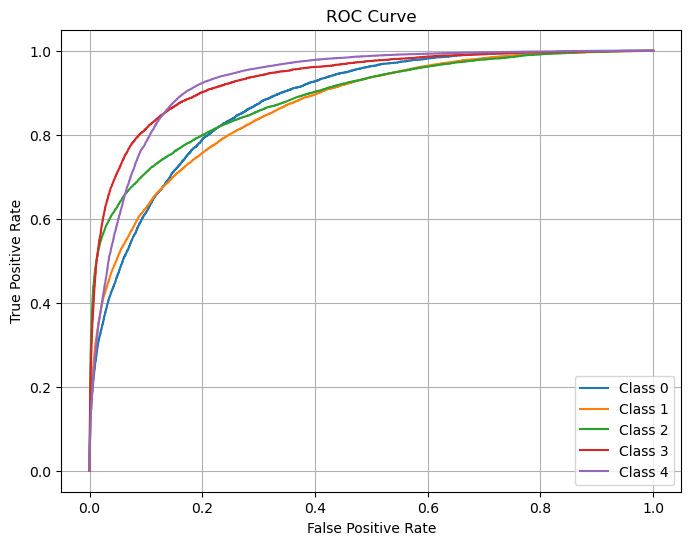

In [17]:
plt.figure(figsize=(8, 6))
for i in range(len(np.unique(y_test_enc))):
    fpr, tpr, _ = roc_curve((y_test_enc == i).astype(int), y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {le.inverse_transform([i])[0]}")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [25]:
#Saving the h5 file
model.save("deep_bilstm_model.h5")
